In [6]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [7]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [8]:
results_dir = f"/hdd/ivny/hedged_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

def extract_signal_mean(signal_str):
    # signal_str format: "mu=0.123, sigma=0.456"
    match = re.search(r"mu=([0-9.]+)", signal_str)
    if match:
        return float(match.group(1))
    else:
        return None

signal_means = []
lc_means = []

original_response = []
calibrated_response = []

for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")

    csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"), index_col=0)
    
    signal_means += csv_data["calibrated_lc"].apply(extract_signal_mean).tolist()
    lc_means += csv_data["calibrated_lc_rewritten_lc"].apply(extract_signal_mean).tolist()
    
    original_response += csv_data["original_response"].tolist()
    calibrated_response += csv_data["calibrated_lc_rewritten_response"].tolist()

    signal_means += csv_data["calibrated_tp"].apply(extract_signal_mean).tolist()
    lc_means += csv_data["calibrated_tp_rewritten_lc"].apply(extract_signal_mean).tolist()

    original_response += csv_data["original_response"].tolist()
    calibrated_response += csv_data["calibrated_tp_rewritten_response"].tolist()

    signal_means += csv_data["calibrated_su"].apply(extract_signal_mean).tolist()
    lc_means += csv_data["calibrated_su_rewritten_lc"].apply(extract_signal_mean).tolist()

    original_response += csv_data["original_response"].tolist()
    calibrated_response += csv_data["calibrated_su_rewritten_response"].tolist()


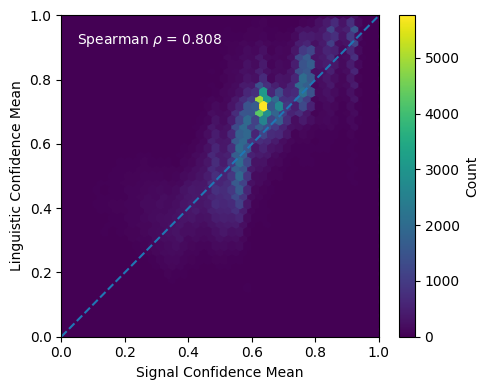

In [9]:
x = np.asarray(signal_means, dtype=float)
y = np.asarray(lc_means, dtype=float)

n = min(len(x), len(y))
x = x[:n]
y = y[:n]

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

rho = spearmanr(x, y)[0]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

hb = ax.hexbin(
    x,
    y,
    gridsize=40,
    extent=(0,1,0,1),
)

ax.plot([0,1],[0,1], linestyle='--')
ax.set_xlabel("Signal Confidence Mean")
ax.set_ylabel("Linguistic Confidence Mean")
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.text(
    0.05, 0.95,
    rf"Spearman $\rho$ = {rho:.3f}",
    transform=ax.transAxes,
    verticalalignment='top',
    color='white',
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count")

plt.tight_layout()
plt.savefig("signal_linguistic_confidence_alignment.pdf", dpi=300, bbox_inches='tight')
plt.show()

Method: TF-IDF cosine similarity (fallback)
Pairs: 256608
Mean similarity: 0.5851
Median similarity: 0.6099
Std similarity: 0.2457


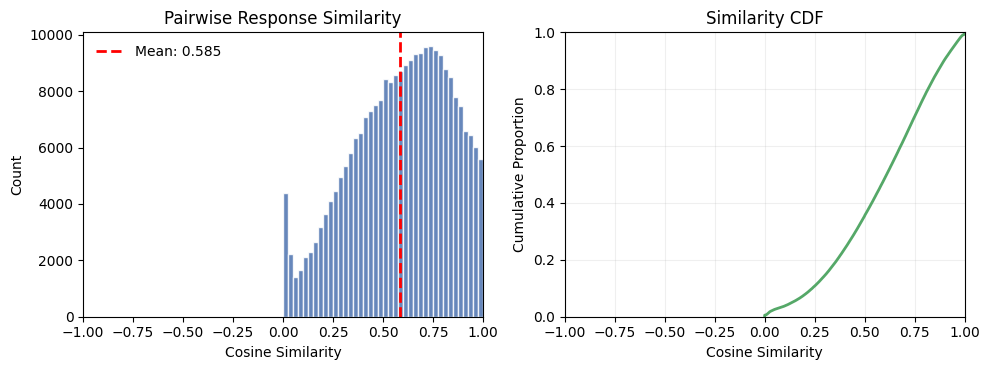

In [10]:
# Semantic similarity between original and calibrated responses
import numpy as np
import matplotlib.pyplot as plt

# Ensure response lists exist (they are populated in Cell 3).
if "original_response" not in globals() or "calibrated_response" not in globals():
    raise NameError("Run Cell 3 first to populate original_response and calibrated_response.")

orig = np.asarray(original_response, dtype=object)
cal = np.asarray(calibrated_response, dtype=object)

n = min(len(orig), len(cal))
orig = orig[:n]
cal = cal[:n]

# Clean null-like values.
orig = np.array(["" if x is None else str(x) for x in orig], dtype=object)
cal = np.array(["" if x is None else str(x) for x in cal], dtype=object)

use_sentence_transformers = True
try:
    from sentence_transformers import SentenceTransformer
except Exception:
    use_sentence_transformers = False

if use_sentence_transformers:
    # Embedding-based semantic similarity.
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    emb_orig = model.encode(orig.tolist(), normalize_embeddings=True, show_progress_bar=True)
    emb_cal = model.encode(cal.tolist(), normalize_embeddings=True, show_progress_bar=True)
    similarities = np.sum(emb_orig * emb_cal, axis=1)
    method_used = "SentenceTransformer cosine similarity"
else:
    # Fallback: lexical similarity if sentence-transformers is unavailable.
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import paired_cosine_distances

    vectorizer = TfidfVectorizer(min_df=2, ngram_range=(1, 2))
    joined = np.concatenate([orig, cal])
    X = vectorizer.fit_transform(joined)
    Xo = X[:n]
    Xc = X[n:]
    similarities = 1.0 - paired_cosine_distances(Xo, Xc)
    method_used = "TF-IDF cosine similarity (fallback)"

similarities = np.asarray(similarities, dtype=float)
similarities = np.clip(similarities, -1.0, 1.0)

sim_mean = float(np.mean(similarities))
sim_median = float(np.median(similarities))
sim_std = float(np.std(similarities))

print(f"Method: {method_used}")
print(f"Pairs: {len(similarities)}")
print(f"Mean similarity: {sim_mean:.4f}")
print(f"Median similarity: {sim_median:.4f}")
print(f"Std similarity: {sim_std:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Histogram
axes[0].hist(similarities, bins=40, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].axvline(sim_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {sim_mean:.3f}")
axes[0].set_title("Pairwise Response Similarity")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-1.0, 1.0)
axes[0].legend(frameon=False)

# CDF for a compact distribution view
sorted_s = np.sort(similarities)
cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].plot(sorted_s, cdf, color="#55A868", linewidth=2)
axes[1].set_title("Similarity CDF")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_xlim(-1.0, 1.0)
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [15]:
# Entailment score between calibrated and original responses using NLI
import os
import numpy as np
import matplotlib.pyplot as plt

# Force writable caches to avoid broken /ssd mount issues in this environment.
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/.cache")
os.environ.setdefault("HF_HOME", "/tmp/.cache/huggingface")
os.environ.setdefault("TRANSFORMERS_CACHE", "/tmp/.cache/huggingface/transformers")
os.environ.setdefault("TORCHINDUCTOR_CACHE_DIR", "/tmp/.cache/torchinductor")

if "original_response" not in globals() or "calibrated_response" not in globals():
    raise RuntimeError("Run the data preparation cell first so original_response and calibrated_response are available.")

pairs = [
    (str(c).strip(), str(o).strip())  # calibrated -> original
    for o, c in zip(original_response, calibrated_response)
    if str(o).strip() and str(c).strip()
]
if not pairs:
    raise RuntimeError("No non-empty response pairs found.")

# Keep runtime practical on very large corpora.
MAX_PAIRS = 20000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
if len(pairs) > MAX_PAIRS:
    idx = rng.choice(len(pairs), size=MAX_PAIRS, replace=False)
    pairs_eval = [pairs[i] for i in idx]
else:
    pairs_eval = pairs

MODEL_ID = "cross-encoder/nli-MiniLM2-L6-H768"
ent_backward = None
method_used = None

# 1) Try local CrossEncoder first (fastest if env is healthy).
try:
    from sentence_transformers import CrossEncoder

    model = CrossEncoder(MODEL_ID)
    logits = model.predict(pairs_eval, batch_size=64, show_progress_bar=True)
    logits = np.asarray(logits, dtype=float)

    if logits.ndim == 1:
        ent_backward = np.clip(logits, 0.0, 1.0)
    else:
        entail_idx = None
        label2id = getattr(model.model.config, "label2id", None)
        if isinstance(label2id, dict):
            for label, lid in label2id.items():
                if "entail" in str(label).lower():
                    entail_idx = int(lid)
                    break

        if entail_idx is None:
            id2label = getattr(model.model.config, "id2label", None)
            if isinstance(id2label, dict):
                for lid, label in id2label.items():
                    if "entail" in str(label).lower():
                        entail_idx = int(lid)
                        break

        if entail_idx is None:
            raise RuntimeError("Could not locate entailment class index from model labels.")

        max_logits = logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits - max_logits)
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        ent_backward = probs[:, entail_idx]

    method_used = f"Local CrossEncoder NLI ({MODEL_ID})"

except Exception as local_err:
    # 2) Fallback: hosted NLI inference via direct HF API requests.
    import requests

    print(f"Local CrossEncoder failed ({type(local_err).__name__}): {local_err}")
    print("Falling back to Hugging Face hosted NLI inference...")

    token = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACEHUB_API_TOKEN")
    headers = {"Authorization": f"Bearer {token}"} if token else {}

    # API fallback is slower; cap sample size for practical runtime.
    MAX_PAIRS_API = 2000
    if len(pairs_eval) > MAX_PAIRS_API:
        idx_api = rng.choice(len(pairs_eval), size=MAX_PAIRS_API, replace=False)
        pairs_eval = [pairs_eval[i] for i in idx_api]
        print(f"Using {MAX_PAIRS_API} pairs for hosted inference fallback.")

    api_models = [MODEL_ID, "facebook/bart-large-mnli"]

    def _call_model(model_id: str, premise: str, hypothesis: str):
        api_url = f"https://api-inference.huggingface.co/models/{model_id}"
        payload = {
            "inputs": {
                "text": premise,
                "text_pair": hypothesis,
            },
            "options": {
                "wait_for_model": True,
            },
        }
        resp = requests.post(api_url, headers=headers, json=payload, timeout=120)
        resp.raise_for_status()
        return resp.json()

    def _entail_prob_api(premise: str, hypothesis: str) -> float:
        last_err = None
        for mid in api_models:
            try:
                out = _call_model(mid, premise, hypothesis)
                if isinstance(out, dict):
                    out = [out]

                entail_p = None
                scores = []
                for item in out:
                    label = str(item.get("label", "")).lower()
                    score = float(item.get("score", 0.0))
                    scores.append(score)
                    if "entail" in label:
                        entail_p = score

                if entail_p is not None:
                    return float(np.clip(entail_p, 0.0, 1.0))
                if scores:
                    return float(np.clip(max(scores), 0.0, 1.0))
            except Exception as e:
                last_err = e
                continue

        raise RuntimeError(f"All hosted NLI models failed. Last error: {last_err}")

    ent_scores = []
    for premise, hypothesis in pairs_eval:
        ent_scores.append(_entail_prob_api(premise, hypothesis))

    ent_backward = np.asarray(ent_scores, dtype=float)
    method_used = "Hosted NLI inference (HF API)"

ent_backward = np.asarray(ent_backward, dtype=float)

print(f"Method: {method_used}")
print(f"Primary model: {MODEL_ID}")
print("Direction: Calibrated -> Original")
print(f"Pairs evaluated: {len(pairs_eval)} / {len(pairs)}")
print(f"Mean entailment: {ent_backward.mean():.4f}")
print(f"Median entailment: {np.median(ent_backward):.4f}")
print(f"Std entailment: {ent_backward.std():.4f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
ax.hist(ent_backward, bins=50, color="#1f77b4", alpha=0.85, density=True)
mean_ent = float(ent_backward.mean())
ax.axvline(mean_ent, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_ent:.3f}")
ax.set_title("Calibrated -> Original Entailment Distribution")
ax.set_xlabel("Entailment probability")
ax.set_ylabel("Density")
ax.legend(frameon=False)
plt.show()

entailment_backward = ent_backward
entailment_scores = ent_backward

Local CrossEncoder failed (AssertionError): Artifact of type=precompile already registered in mega-cache artifact factory
Falling back to Hugging Face hosted NLI inference...
Using 2000 pairs for hosted inference fallback.


RuntimeError: All hosted NLI models failed. Last error: 410 Client Error: Gone for url: https://api-inference.huggingface.co/models/facebook/bart-large-mnli